<p>The goal of this parctical lab is to implement a decision tree classifier</p>
<p>Pseudocode</p>
DecisionTree:
 <ol>
  <li="1">if(stopping condition): retrun decision for this node</li>
  <li>For each possible feature</li>
    <li><p STYLE="padding:0 0 0 20px;">For each possible split </p></li>
    <li><p STYLE="padding:0 0 0 40px;">Compute split points </p></li>
    <li><p STYLE="padding:0 0 0 40px;">Score the split using information gain </p></li>
  <li>Take the feature and the split with the best score</li>
  <li>Split the data points</li>
  <li>Recurse on each subset</li>
</ol>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
# Generate 200 2d feature points and their corresponding binary labels.
X = np.random.rand(200, 2)
y = np.zeros(200)
y[np.where(X[:,0]<X[:,1])] = 1

In [3]:
# Create color maps
cmap_light = ListedColormap(['#AAAAFF', '#FFAAAA'])
cmap_bold = ListedColormap(['#0000FF', '#FF0000'])

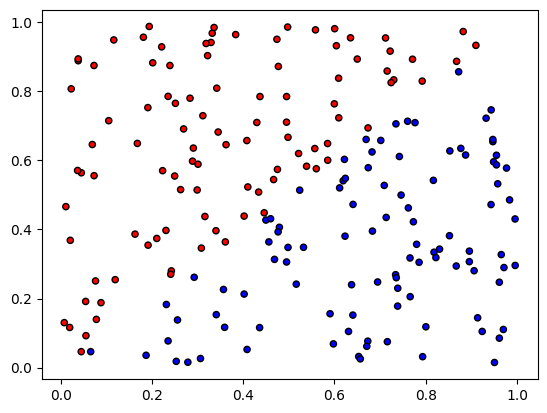

In [4]:
# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,
            edgecolor='k', s=20)

<p> Write a python class called Question used to partition the dataset :</p>
<p> The training data could be seen as a table composed of 3 columns [X, Y] and 200 rows </p>

# Implement the Question class

In [5]:
class Question:
    """A Question is used to partition a dataset.
    """

    def __init__(self, column, value):
        self.column = column
        self.value = value

    def match(self, example):
        # Compare the feature value in an example to the
        # feature value in this question.
        val = example[self.column]
        return val >= self.value

<p> For each row in the dataset, check if it matches the question. If
    so, add it to 'true rows', otherwise, add it to 'false rows'.
    </p>

In [6]:
def split(rows, question):
    true_rows, false_rows = [], []
    for row in rows:
        if question.match(row):
            true_rows.append(row)
        else:
            false_rows.append(row)
    return true_rows, false_rows


# Gini Impurity (or Entropy)

In [7]:
def class_counts(rows):
    counts = {}
    for row in rows:
        label = row[-1]
        if label not in counts:
            counts[label] = 0
        counts[label] += 1
    return counts

In [8]:
def gini(rows):
    #Class_counts counts the number of each type of example in a dataset.
    counts = class_counts(rows)
    impurity = 1
    for lbl in counts:
        prob_of_lbl = counts[lbl] / float(len(rows))
        impurity -= prob_of_lbl**2
    return impurity

In [24]:
# def entropy(rows):
#     labels = rows[:, -1]
#     counts = np.unique(labels, return_counts=True)[1]
#     probs = counts / len(labels)
#     return -np.sum(probs * np.log2(probs))


# Information Gain

In [10]:
def info_gain(left, right, current_uncertainty):
    p = float(len(left)) / (len(left) + len(right))
    return current_uncertainty - p * gini(left) + (1 - p) * gini(right)

<p> Find the best question to ask by iterating over every feature / value
    and calculating the information gain </p>

# The best split

In [11]:
def optimal_split(rows):
    best_gain = 0  # keep track of the best information gain
    best_question = None  # keep train of the feature / value that produced it
    current_uncertainty = gini(rows)
    n_features = len(rows[0]) - 1  # number of columns

    for col in range(n_features):  # for each feature

        values = set([row[col] for row in rows])  # unique values in the column

        for val in values:  # for each value

            question = Question(col, val)

            # try splitting the dataset
            true_rows, false_rows = split(rows, question)

            # Skip this split if it doesn't divide the
            # dataset.
            if len(true_rows) == 0 or len(false_rows) == 0:
                continue

            # Calculate the information gain from this split
            gain = info_gain(true_rows, false_rows, current_uncertainty)

            if gain >= best_gain:
                best_gain, best_question = gain, question

    return best_gain, best_question


A Leaf node classifies data. This holds a dictionary of class (e.g., "die") -> number of times it appears in the rows reaching this leaf.

In [13]:
class Leaf:
    def __init__(self, rows):
        counts = class_counts(rows)
        total = sum(counts.values())
        self.predictions = {label: count/total for label, count in counts.items()}


In [25]:
# class Leaf:
#     def __init__(self, rows):

#       self.predictions = class_counts(rows)

A Decision Node asks a question. This holds a reference to the question, and two child nodes.

In [17]:
class Decision_Node:
    def __init__(self, question, true_branch, false_branch):

        self.question = question
        self.true_branch = true_branch
        self.false_branch = false_branch


# Recursive Tree Building

In [20]:
def decisionTree(rows):
    gain, question = optimal_split(rows)

    # Stopping condition: If no further information gain, return a Leaf node.
    if gain == 0:
        return Leaf(rows)

    # If we got here, we've found a useful split. (optimal_split returned a question)
    true_rows, false_rows = split(rows, question)

    # Recursively build the true branch.
    true_branch = decisionTree(true_rows)

    # Recursively build the false branch.
    false_branch = decisionTree(false_rows)

    # Return a Decision_Node node.
    return Decision_Node(question, true_branch, false_branch)

# Prediction Function

In [21]:
def classify(row, node):
    """See what the tree predicts for a given row."""

    if isinstance(node, Leaf):
        return node.predictions

    if node.question.match(row):
        return classify(row, node.true_branch)
    else:
        return classify(row, node.false_branch)

# All in one place

In [37]:
class DecisionTree:
    def __init__(self, max_depth=None):
        pass

    def fit(self, X, y):
        data = np.column_stack((X, y))
        self.tree = decisionTree(data)

    def predict(self, X):
        preds = []
        for row in X:
            leaf = classify(row, self.tree)
            # choose the most common class
            preds.append(max(leaf, key=leaf.get))
        return np.array(preds)

    def accuracy(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


Fit the Decision Tree

In [26]:
dt = DecisionTree()
dt.fit(X, y)

In [27]:
def print_tree(node, spacing=""):

    # Base case: leaf
    if isinstance(node, Leaf):
        print(spacing + "Predict:", node.predictions)
        return

    # Print the question
    print(spacing + f"[X[{node.question.column}] >= {node.question.value}]?")

    # True branch
    print(spacing + '--> True:')
    print_tree(node.true_branch, spacing + "  ")

    # False branch
    print(spacing + '--> False:')
    print_tree(node.false_branch, spacing + "  ")

In [28]:
print_tree(dt.tree)

[X[0] >= 0.9958623117998456]?
--> True:
  Predict: {np.float64(0.0): 1}
--> False:
  [X[0] >= 0.9956449781543537]?
  --> True:
    Predict: {np.float64(0.0): 1}
  --> False:
    [X[1] >= 0.987554663039844]?
    --> True:
      Predict: {np.float64(1.0): 1}
    --> False:
      [X[0] >= 0.9836125581900629]?
      --> True:
        Predict: {np.float64(0.0): 1}
      --> False:
        [X[1] >= 0.9859006509239272]?
        --> True:
          Predict: {np.float64(1.0): 1}
        --> False:
          [X[0] >= 0.9769384838011002]?
          --> True:
            Predict: {np.float64(0.0): 1}
          --> False:
            [X[1] >= 0.9845715960792342]?
            --> True:
              Predict: {np.float64(1.0): 1}
            --> False:
              [X[0] >= 0.9713136950533457]?
              --> True:
                Predict: {np.float64(0.0): 1}
              --> False:
                [X[1] >= 0.9811052374494154]?
                --> True:
                  Predict: {np.float64(1.

# Learning Curve (Training Size vs Accuracy)

In [29]:
def learning_curve(model, X, y, steps=20):
    sizes = np.linspace(20, len(X), steps).astype(int)
    accuracies = []

    for s in sizes:
        model.fit(X[:s], y[:s])
        preds = model.predict(X)
        acc = model.accuracy(X, y)
        accuracies.append(acc)

    return sizes, accuracies

In [30]:
sizes, accs = learning_curve(DecisionTree(), X, y)

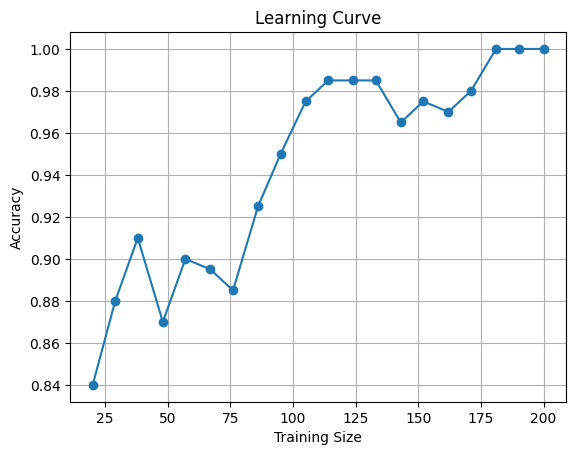

In [31]:
plt.plot(sizes, accs, marker='o')
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.grid(True)
plt.show()

# Confusion matrix

In [41]:
import numpy as np

def confusion_matrix_report(y_true, y_pred):
    """
    Compute and print a confusion matrix using only NumPy.
    Works for binary or multi-class classification.
    """

    # Identify unique classes
    classes = np.unique(np.concatenate((y_true, y_pred)))
    n_classes = len(classes)

    # Create empty confusion matrix
    cm = np.zeros((n_classes, n_classes), dtype=int)

    # Fill matrix
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1

    # Print header
    print("\nConfusion Matrix:")
    print(" " * 12 + "Predicted")
    header = " " * 10 + " | " + "  ".join([f"{c:>6}" for c in classes])
    print(header)
    print("-" * len(header))

    # Print rows
    for i, c in enumerate(classes):
        row_vals = "  ".join([f"{cm[i, j]:>6}" for j in range(n_classes)])
        print(f"Actual {c:>3} | {row_vals}")

    return cm


In [42]:
y_pred = dt.predict(X)
confusion_matrix_report(y, y_pred)



Confusion Matrix:
            Predicted
           |    0.0     1.0
---------------------------
Actual 0.0 |    101       0
Actual 1.0 |      0      99


array([[101,   0],
       [  0,  99]])

# Decision Boundary

In [43]:
def plot_decision_boundary(model, X, y):
    xx, yy = np.meshgrid(
        np.linspace(0, 1, 200),
        np.linspace(0, 1, 200)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors='k')
    plt.title("Decision Boundary")
    plt.show()

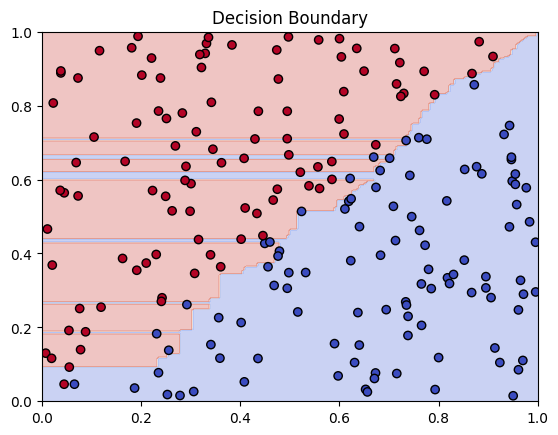

In [44]:
plot_decision_boundary(dt, X, y)

# expermentation on the breast IRIS dataset

In [49]:
from sklearn.datasets import load_iris
import numpy as np

data = load_iris()
X = data.data
y = data.target

print("Iris dataset loaded:", X.shape, y.shape)


Iris dataset loaded: (150, 4) (150,)


In [50]:
dt2 = DecisionTree()
dt2.fit(X, y)

In [51]:
y_pred = dt2.predict(X)

In [52]:
dt2.accuracy(X, y)

np.float64(1.0)

In [53]:
confusion_matrix_report(y, y_pred)


Confusion Matrix:
            Predicted
           |    0.0     1.0     2.0
-----------------------------------
Actual 0.0 |     50       0       0
Actual 1.0 |      0      50       0
Actual 2.0 |      0       0      50


array([[50,  0,  0],
       [ 0, 50,  0],
       [ 0,  0, 50]])

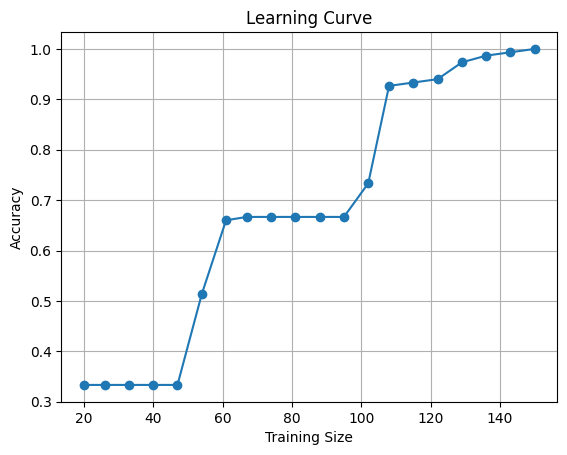

In [54]:
sizes, accs = learning_curve(dt2, X, y)

plt.plot(sizes, accs, marker='o')
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.grid(True)
plt.show()

# expermentation on the breast Wine dataset

In [56]:
from sklearn.datasets import load_wine
import numpy as np

data = load_wine()
X = data.data
y = data.target

print("Wine dataset loaded:", X.shape, y.shape)


Wine dataset loaded: (178, 13) (178,)


In [57]:
dt3 = DecisionTree()
dt3.fit(X, y)

In [58]:
y_pred = dt2.predict(X)

In [59]:
dt2.accuracy(X, y)

np.float64(0.21348314606741572)

In [60]:
confusion_matrix_report(y, y_pred)


Confusion Matrix:
            Predicted
           |    0.0     1.0     2.0
-----------------------------------
Actual 0.0 |      0       0      59
Actual 1.0 |      4       0      67
Actual 2.0 |     10       0      38


array([[ 0,  0, 59],
       [ 4,  0, 67],
       [10,  0, 38]])

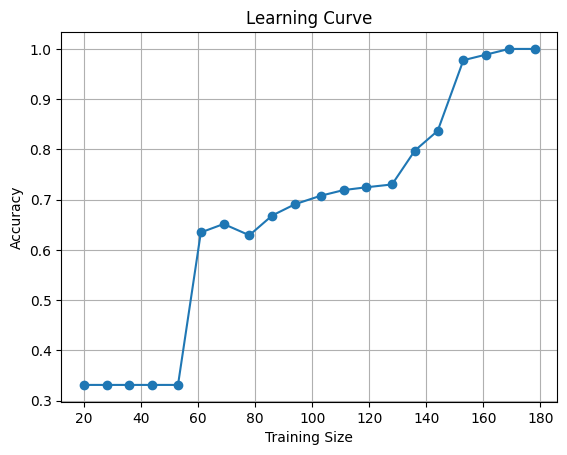

In [61]:
sizes, accs = learning_curve(dt2, X, y)

plt.plot(sizes, accs, marker='o')
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.grid(True)
plt.show()